# Simple Models in Economics

In economics we use a lot of different mathematical models to describe enviroments. We already discussed simple two good supply-demand model and found a computational way we can solve for equilibrium. In this lecture we discuss 3 other simple economic models and computational solutions. I selected those three models mainly because, they are very different from each other, so it will help us cover a wide range of models.

I borrow all three models from QuantEcon project!

## Example 1: Investment Problem

A mutual fund has \$100 000 to invest over three year horizon. There are three investment options.

1. **Annuity:** Fund can invest the same amount at the begining of years 1, 2, and 3 and get 130\% return at the end of year 3 of total capital. 
2. **Bank account:** Fund can invest any amount at the begining of each year to get capital plus 6\% return at the end of each year. They can also borrow \$20 000 at the begining of each year to pay back back borrowed amount plus 6\% at the end of the year.
3. **Corporate bond:** from year 2, a corporate bond becomes available and the fund can invest no more than $50 000. In fund invests, they will get 130\% at the end of the third year. 

Obviously, the mutual fund wants to maximize total payout. Let's reframe this as linear programming problem.

**Decision variables:**
- $x_1$: amount to put in annuity (in every year)
- $x_2$, $x_3$, $x_4$: bank balances at the begining of each year, if negative indicates borrowing.
- $x_5$: the corporate bond investment

Table below describes timeline of each investment.


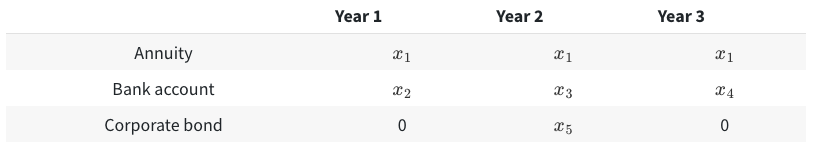

Let's write down mutual funds optimization problem. 

**The objective functions:** 

1. Fund invests $3x_1$ in annuity to get $1.30\cdot 3x_1$ 
2. At the begining of year 3 fund has $x_4$ on the bank account and will get 6\% return on it, $1.06x_4$
3. Fund can invest $x_5$ in the corporate bond to get $1.30x_5$ at the end of year 3. 

So in total, fund will have:
$$1.30\cdot 3x_1 + 1.06x_4 + 1.30x_5$$

**Constraints:** 
1. At the begining of the first year fund can split 100 000 between annuity and bank: $x_1+x_2=100 000$
2. At the begining of the second year, fund gets $1.06x_2$ from investing $x_2$ in the first year: $x_1+x_3+x_5=1.06x_2$ **Notice**, $x_3$ could be negative indicating fund borrowed in that time period from the bank.
3. At the begining of the third year, fund has bank balance $1.06x_3$ (either positive or negative amount). In year 3 $x_1$ goes to annuity and $x_4$ (positive or negative amount) to bank: $x_1+x_4=1.06x_3$


We can rewrite all of this in linear programming framework:

\begin{split}
\begin{aligned}
\max_{x} \ & 1.30 \cdot 3x_1 + 1.06 x_4 + 1.30 x_5 \\
\mbox{subject to } \ & x_1 + x_2 = 100,000\\
 & x_1 - 1.06 x_2 + x_3 + x_5 = 0\\
 & x_1 - 1.06 x_3 + x_4 = 0\\
 & x_2 \ge -20,000\\
 & x_3 \ge -20,000\\
 & x_4 \ge -20,000\\
 & x_5 \le 50,000\\
 & x_j \ge 0, \quad j = 1,5\\
 & x_j \ \text{unrestricted}, \quad j = 2,3,4\\
\end{aligned}
\end{split}

In [1]:
# import modules

import numpy as np
import pandas as pd

from scipy.optimize import linprog
import matplotlib.pyplot as plt


In [1]:
# Objective function parameters



# equality constraints






# Bounds on decision variables





# Solve the problem





So here is the recomendation from the optimizatio outcome:

**First year: the fund has 100k**

- Invest around 24927.75 on annuity 
- Invest the remaining 75072.25 in bank to get 6\% return

**Second year: the fund has 75072.25*1.06 = 79576.59k**
- Invest around 24927.75 on annuity again (remmember you are restrected to invest the same amount every year on annuity)
- Invest 50k on corporate bond
- Invest the remaining 79576.59 - 50 000 - 24927.75 = 4648.84 in bank

**Third year: the fund has 4648.84*1.06 = 4927.77**

- Need to invest another 24927.75 in annuity, but has access to 4927.77, so borrow from bank 20k

## Schelling’s Segregation Model

Thomas C. Schelling developed a simple but striking model of racial segregation. He got the 2005 Nobele Prize in Economics for this and other similar research he did. We will use this model to demosntrate how we can solve theoretical model computationally. This is not a general model, but it is one type of model that economists use.

**Set up:**
- We have two types of agents: 250 orange agents and 250 green agents
- They all live on a single unit square (will be clear later)
- Each agent has a location (x, y), where $x\in(0, 1)$ and $y\in(0, 1)$

**Preferences:**

Preferences depend on 10 nearest neighbors (in term of euclidian distance). An agent is happy if at least half of the 10 nearest neighbors are the same type and unhappy otherwise.

**Actions:**

Agent can move of stay based on happiness. 

**Timeline:**

1. Agents are randomly allocated in a unit squre, in other words, their location is randomly drawn from bivariate uniform distribution from (0, 1).

2. In every period, each agent simultaniously decided to move or stay:
    - Stay if happy
    - Move if unhappy and draw new location from bivariate uniform distribution from (0, 1)

Game continues until eveyrone is happy! 

**Soluton:**

We solve the game by coding it in python and show how fast agents segregate even though they are not really averse to living in a mixed neighborhoods. They just don't want to live in a neighborhood where most of their neighbors are different type. 

There are many, many, many .... ways one can code this up, but below is the version that I wrote. Feel free to improve it!

In [3]:
# Draw from bivariate random uniform, and namne columns as 'x' and 'y'





# Since all the agents are randomly allocated at first, let's say the first 250 are orange and the last 250 green.
# We know that, computationally, integer is more memorry efficient than string, so insted of creating column 
# something like agent's color, we create, a column 'orange' which equals 1 if the agent is orange and 0 if green





In [4]:
# we use scatterplot to show them on unit square





We need to write a code which will move agents based on their happiness. The general idea should follow those steps:

- Step 1: calculate distance between a given agent and everyone else
- Step 2: find who are the 10 closest neighbors
- Step 3:
    - if at least 5 of those 10 are similar type, the agent stays
    - otherwise the agent moves and draw new location randomly from the same distribution
    
We need to loop over those three steps until no agent is willing to move.

In [5]:
# We will use the "while" loop to achove our goal.
# the get while loop started we need some "True" conditio and to end the same while loop, the same condition
# should change to false at some point. To achive that we create variable outside the loop and make sure 
# it is true first and keep updating it in each iteration. 
# We define two variables, unhappy. The while loop will run until at least one person is unhappy. 
# So let's assign initial value to unhappy = 1 (it could be anythin as long as it satisfies while loop)




# In order to count how many iterations it takes to converge (nobody to be willing to move) we also define iteration 
# as zero and increae this nunmber by one each time while loop happens




# as we said, in order to get the while loop started, the initial condition should be true. By initial assignment
# unhappy=1 so  it is > 0:



    # create a placeholder where we store all the agents that moved.

    
    # to keep the original data unafected until all the agents decide to move or not in each iteration
    # we make a copy of it
    

    
    
    # now we loop over each agent to see if they want to move or not

    
        # their moving decision depends on number of similar types aroud the agent. We calculate distance manually
        # one step at a time, but you can put all in one line
        
        # first calculate elementwise difference between the given agents lication and everyone esle

        
        # square each coordinate difference
        

        
        # sum squares of differences

        
        # take  a square toot from the sum

        
        # in the temporary dataframe add a column which containes distance between a given agent and everyone else
        # includine the agent hersels (the distance between agent and herself should be zero)

        
        
        # Now we use little trick. After we sort the data by distance, we need to find if at least
        # five neighbors are similar type. In the sorted version, the closest agent will be, agent herself.
        # So we need to look at closes agents from the second closes to 10th closess, which in python will be [1:11].
        # We compare type of the given agent to all of them. If types coincide we get True, if not we get False
        # for python True is 1 and False is 0. If we sum this True-False values (of length 10), 
        # we can get any number from 0 (in this case all the neighbors are other type) to 
        # 10 (in this case all the neighbors are the same type)
        # The agent will be unhappy if less then five are the same type, so the agent is unhappy if the number is <5.

        
            # if the condition is met, the agent is unhappy and moves. 
            # We will append list "moved" where we store all the agents who moved in a given iteration

            
            # Since the agent moves we will update her location in the original(!!!) data not in the copied version! 

            
    # After we check every agent, we find how many people where unhappy and if number is more than 0 while loop continues

    
    # At this point the iteration is done and we increase it by one to keep the record of how many iterations we are doing

    
    # to keep infromation coming at every iteration we print out what is happening in our code

    

    
        
   

In [6]:
# now let's visualize the final lcoations:



## Shortest Paths

Another interesting and very useful model used in economics, transportation, network design etc is the shortest path problem. The most well-known example could be the Google Maps!

The idea is as follows, we need to get from point A to point B. There are many different ways to get there, and we need to find the shortest one. In economics, it could be something like: we need to produce $x$ amoint of products, therea re many different ways and each ways is assosiated with some cost, if we need to find the most cost efficient way, we can use shortest path algorithm. 

Let's use the example from QuantEcon:

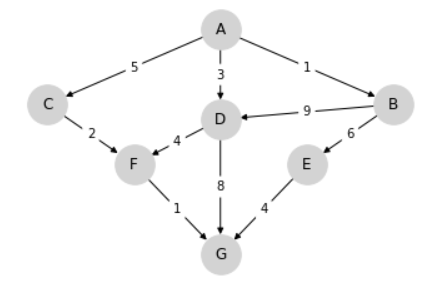

Here the problem is finding the best path from point $A$ to point $G$.

Graph description:
- Each arrow indicates where you can go from a given point
- Numbers on edges indicate the cost of traveling on that edge

Obviously, finding a shortes (the most cost efficient) path on the graph above is trivial and requres no computer intervention, but things could get very comlicated very fast if we add more nodes, so we need to have some kind of systematic way of solving such problems.

**Algorithm**

Let $J(v)$ denote the minimum cost path from node $v$. Of course we do not know $J(v)$ (if we knew we would have just selected the shortest one from the initial node). 

An algorithm to find the best path foloows the following steps:

1. Start at $v=A$
2. From current node $v$ move to any node that solves:

$$\min_{w\in F_v} \{c(v, w) + J(w)\}$$

where:
- $F_v$ is the set of nodes that can be reached from $v$ in one step
- $c(v, w)$ is the cost of traveling from $v$ to $w$
    
To solve such problems, Richard Bellman introduced the following equation, which is now called Bellman equation:

$$J(v)=\min_{w\in F_v} \{c(v, w) + J(w)\}$$

The Bellman equation is very widely used in economics and in many other disciplines. The idea is simple, but it is not easy to work with. So, let's explain the intuation based on the shortest path example:

The shortest path ($J$) from a current node is the same as the shortest path from the subsequent node if that subsequent node is the next node from the curent one. For example, if we know that to get from point T to point H, the shortest path is T=>L=>M=>U=>K=>H, then the shortest path from L to H will be L=>M=>U=>K=>H, or in other words the same path started from L. 


Sometimes you can find analytical solution for $J$ but more often people use algorithms to solve Bellman eqation.

The standard algorithm for finding $J$ follws guess-iterate steps.

Guess:

Let's start with guess $J_0(v)=0$ for all $v$ (of course this is not going to solve the Bellman equation, but we start from there).

Iterate:

1. Start $n=0$
2. Calculate $J_{n+1}(v)$ for every $v$ from $J_{n+1}(v)=\min_{w\in F_v} \{c(v, w) + J_n(w)\}$ 
3. If $J_{n+1}$ and $J_{n}$ are not equal increase $n$ by 1 and go bac to step 2.



This sequence will converge to $J$. In other words at some point we will find that $J_{n+1}=J_{n}$ which we will denote by $J$ and it will be our solution.

Now lets impliment it in Python!

The first thing we need to do is define destance matrix, which summarizes all the information about the graph. For the nodes that are directly connected, for example, (A, C), (B, D), (B, E), etc, defining the destance is straitforwad. The cost of traveling from A to C is 5 and that will be our distance, simlarly, the cost of traveling from A to  B is 1 and that will be uor distance. But what about the nodes that are not directly connected, for example (A, E), (B, F), (B, C) etc. Here we use simple trick, we still "allow", computer to travel directly from A to E and B to F or B to C, but we will say that the travel cost (distance) to directly travel between those nodes is infinit (or most of the time some very very very large number could work). Formally, we can write this as:

$$Q(v, w)=\begin{cases}  c(v, w) \text{ if } w \in F_v \\ +\infty \text{ otherwise } \end{cases} $$

Where $c(v, w)$ is the cost of traveling from node $v$ to $w$. $F_v$ is the set of nodes that can be reached by one step from node $v$. We call $Q$ distance matrix. Let's construct $Q$ for the graph above.

In [1]:
# Looking at the algorithm, we nee to define J_n, J_n+1 and c(v, w). We define all c(v, w) within matrix Q.


# since we will use a lot of infinity, in order not to write evey time np.inf, we can just assign variable to np.inf



# Create matrix Q




In [2]:
# Version 1 with loops: (more intuative but less efficient)
# Now define J_0 and J_1 that we will keep updating so they are the same as J_n and J_n+1
# we have total of 7 nodes



# initial guess of J and vector where we store all J_n values



# empty vector where we store all J_n+1 values 




# we need to have termination rule for the while loop to avoid running the code forever:




# true condition to start the while loop


    # in each step we need to calculate minimum cost move from each node 

    
        # minimize c[v, w] + J[w] over all choices of w and store them as J_n+1
        #to do that we initialize lowest possible cost as infinity

        
        # now from node v to each node we will calculate cost
        
        
        
            # compare if that cost is lower than already existed lowest_cost
            
                # if is, update the lowest cost
                
                # when we exit the for loop assign lowest cost to node v in J_n+1
        

        
    # if J_n and J_n+1 are equal, break the loop.  
    
        

    
        # if they are not equal update J_n and go to the next iteration
    
        
        # we need to update 
        
        
    #print
    



In [3]:
# Version 2 with matrix operations: (less intuative but more efficient)

# Now define J_0 and J_1 that we will keep updating so they are the same as J_n and J_n+1

# we have total of 7 nodes
      

# initial guess of J and vector where we store all J_n values
       

# empty vector where we store all J_n+1 values 
  

# we need to have termination rule for the while loop to avoid running the code forever:



# true condition to start the while loop


    # in each step we need to calculate minimum cost move from each node 
    
        # minimize c[v, w] + J[w] over all choices of w and store them as J_n+1
        
        
    # if J_n and J_n+1 are equal, break the loop.  
    
        
    
        # if they are not equal update J_n and go to the next iteration
          
        # we need to update 
        

#print

